### cv2.filter2D
universal function that accept to apply your own linear filters for different points:
* all coefficients are same - averaging and blur
* central coefficient is greater than others - possibly sharpness increasing
* positive and negative coefficients - changes in brightness and contours can be detected
* sum of coefficients equals zero - the Kernel often used for spatial changes of intensity

O(H W N), if N > 11 using the Fourier transform

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from core.entities.constants import Paths as p

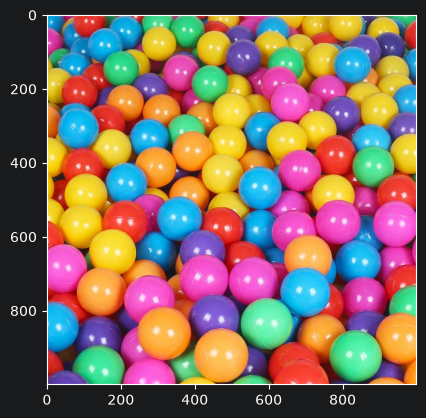

In [2]:
image_path = p.IMAGE_ASSETS / "colored_balls.jpg"

img = cv2.imread(image_path, cv2.IMREAD_COLOR_RGB)
plt.figure()
plt.imshow(img)

# BLUR
the kernel has same coefficients

In [12]:
k_size = 50
kernel = np.ones((k_size, k_size), np.float32) / (k_size*k_size)
kernel

array([[0.0004, 0.0004, 0.0004, ..., 0.0004, 0.0004, 0.0004],
       [0.0004, 0.0004, 0.0004, ..., 0.0004, 0.0004, 0.0004],
       [0.0004, 0.0004, 0.0004, ..., 0.0004, 0.0004, 0.0004],
       ...,
       [0.0004, 0.0004, 0.0004, ..., 0.0004, 0.0004, 0.0004],
       [0.0004, 0.0004, 0.0004, ..., 0.0004, 0.0004, 0.0004],
       [0.0004, 0.0004, 0.0004, ..., 0.0004, 0.0004, 0.0004]],
      shape=(50, 50), dtype=float32)

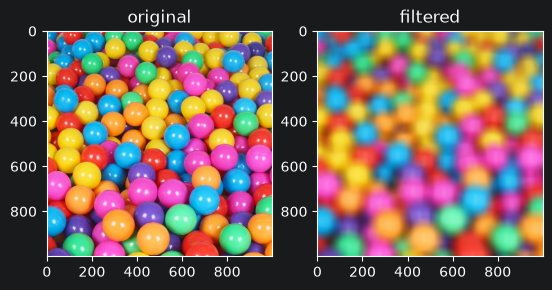

In [13]:
filtered = cv2.filter2D(img, -1, kernel)
plt.figure()
plt.subplot(121)
plt.title("original")
plt.imshow(img)

plt.subplot(122)
plt.title("filtered")
plt.imshow(filtered)



1. Визначає локальне вікно (k_size * k_size).
2. Множить кожен піксель на відповідний коефіцієнт ядра.
3. Складає дев'ять результатів.
4. Записує отримане значення у відповідну позицію вихідного зображення.
5. Повторює операцію для інших пікселів.
Оскільки всі дев'ять коефіцієнтів однакові, результат дорівнює середній інтенсивності локального вікна.

# Sharpening

In [15]:
kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
], dtype="float32")
kernel

array([[ 0., -1.,  0.],
       [-1.,  5., -1.],
       [ 0., -1.,  0.]], dtype=float32)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1843138..2.1882353].


(np.float64(-0.5), np.float64(999.5), np.float64(999.5), np.float64(-0.5))

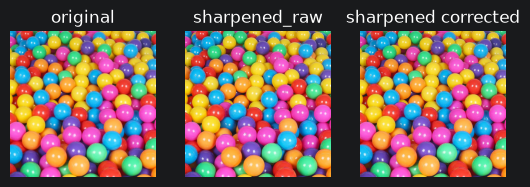

In [22]:
sharpened_raw = cv2.filter2D(img, cv2.CV_32F, kernel)
sharpened_corrected = np.clip(sharpened_raw, 0, 255).astype("uint8")

plt.figure()
plt.subplot(131)
plt.title("original")
plt.imshow(img)
plt.axis('off')

plt.subplot(132)
plt.title("sharpened_raw")
plt.imshow(sharpened_raw / 255.0)
plt.axis('off')

plt.subplot(133)
plt.title("sharpened corrected")
plt.imshow(sharpened_corrected)
plt.axis('off')

# extraction of horizontal and vertical contours

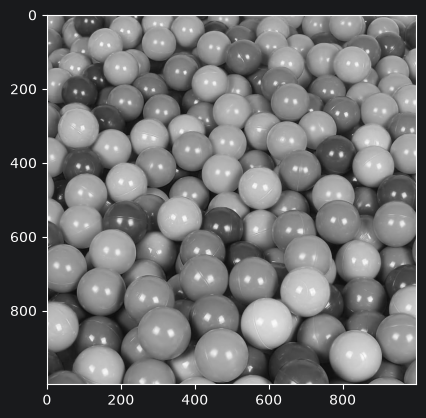

In [25]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.figure()
plt.imshow(gray, cmap="gray")

In [26]:
kernel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype="float32")
kernel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype="float32")

(np.float64(-0.5), np.float64(999.5), np.float64(999.5), np.float64(-0.5))

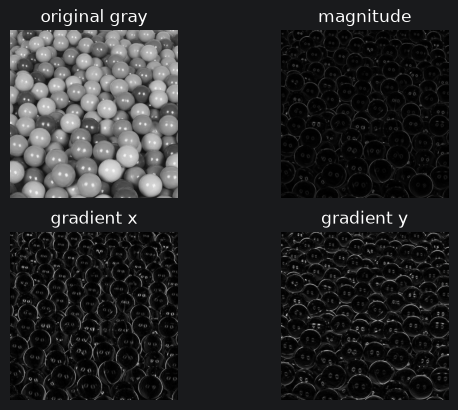

In [28]:
# save signs

grad_x = cv2.filter2D(gray, cv2.CV_32F, kernel_x)
grad_y = cv2.filter2D(gray, cv2.CV_32F, kernel_y)

# Обчислюємо модуль відгуку для візуалізації
abs_x = cv2.convertScaleAbs(grad_x)
abs_y = cv2.convertScaleAbs(grad_y)

# Об'єднуємо компоненти градієнта
magnitude = cv2.magnitude(grad_x, grad_y)

# Масштабуємо результат для відображення
magnitude_vis = cv2.normalize(
    magnitude,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

cmap = plt.get_cmap("gray")

plt.figure()
plt.subplot(221)
plt.title("original gray")
plt.imshow(gray, cmap=cmap)
plt.axis('off')

plt.subplot(222)
plt.title("magnitude")
plt.imshow(magnitude, cmap=cmap)
plt.axis('off')

plt.subplot(223)
plt.title("gradient x")
plt.imshow(abs_x, cmap=cmap)
plt.axis('off')

plt.subplot(224)
plt.title("gradient y")
plt.imshow(abs_y, cmap=cmap)
plt.axis('off')